In [19]:
pip install -U imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE                         
from sklearn.metrics import precision_recall_curve   
from sklearn.metrics import classification_report
from sklearn.feature_selection import SelectFromModel
from yellowbrick.model_selection import FeatureImportances 

In [21]:
data = pd.read_csv(filepath_or_buffer = "creditcard_csv.csv")
data.shape

(284807, 31)

In [22]:
data.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,'0'
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,'0'
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,'0'
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,'0'
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,'0'
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,'0'
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,'0'
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,'0'
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,'0'
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,'0'


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [24]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,94813.859575,3.918649e-15,5.682686e-16,-8.761736e-15,2.811118e-15,-1.552103e-15,2.040130e-15,-1.698953e-15,-1.893285e-16,-3.147640e-15,...,5.126845e-16,1.473120e-16,8.042109e-16,5.282512e-16,4.456271e-15,1.426896e-15,1.701640e-15,-3.662252e-16,-1.217809e-16,88.349619
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000


In [25]:
bool_res = data.duplicated().any()
print(f"bool_res:: {bool_res}")

bef_drop = data.shape[0]
print(f"shape of the dataframe before dropping duplicates :: {data.shape}")
print(f"bef_drop :: {bef_drop}")

data.drop_duplicates(inplace=True)

after_drop = data.shape[0]
print(f"shape of the dataframe after dropping duplicates :: {data.shape}")
print(f"after_drop :: {after_drop}")


print(f"percentage of duplicates :: {((bef_drop-after_drop)/bef_drop)*100} ")

bool_res:: True
shape of the dataframe before dropping duplicates :: (284807, 31)
bef_drop :: 284807
shape of the dataframe after dropping duplicates :: (283726, 31)
after_drop :: 283726
percentage of duplicates :: 0.379555277784605 


## Exploratory Data Analysis

1. Distribution of fraudulent and non-fraudulent transactions?

In [26]:
data['Class'].value_counts()

'0'    283253
'1'       473
Name: Class, dtype: int64

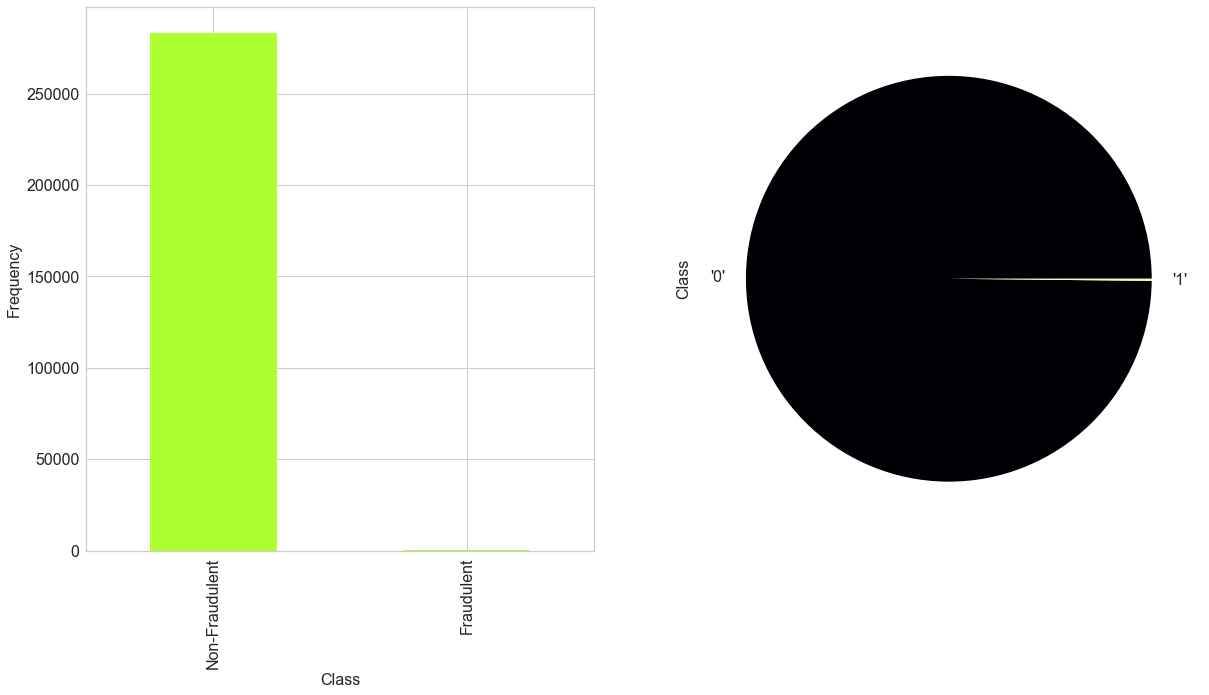

In [27]:
paper=plt.figure(figsize=[20,10])
plt.subplot(1,2,1)
data['Class'].value_counts().plot.bar(color = "greenyellow")
plt.xticks(ticks = [0,1],labels = ['Non-Fraudulent','Fraudulent'],size=16)
plt.yticks(size=16)
plt.xlabel(xlabel="Class",size=16)
plt.ylabel(ylabel="Frequency",size=16)
plt.grid(visible = True)

plt.subplot(1,2,2)
data['Class'].value_counts().plot(kind='pie',fontsize=16,cmap='inferno')
plt.ylabel(ylabel="Class",size=16)
plt.show()

Is there any relation  of fraudulent and non-fraudulent transactions with respect to time:

In [28]:
data['Time(in_hours)'] = data['Time']/3600

C:\Users\admin\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\admin\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


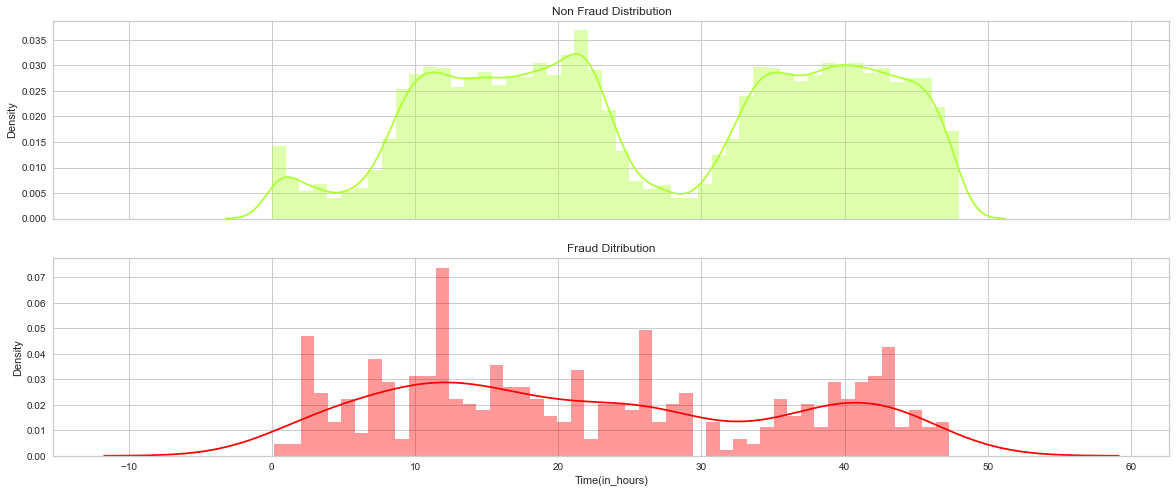

In [29]:
nonfraud = data['Time(in_hours)'][data['Class'] == "'0'"]
fraud = data['Time(in_hours)'][data['Class'] == "'1'"]
fig ,(ax1,ax2)=plt.subplots(nrows=2,ncols=1,sharex=True,figsize=[20,8])
sns.distplot(a=nonfraud,bins=50,hist=True,kde=True,color='greenyellow',ax=ax1)
ax1.set_title('Non Fraud Distribution')
sns.distplot(a=fraud,bins=50,hist=True,kde=True,color='red',ax=ax2)
ax2.set_title('Fraud Ditribution')
plt.show()

Is there any relation  of fraudulent and non-fraudulent transactions with respect to amount:

C:\Users\admin\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


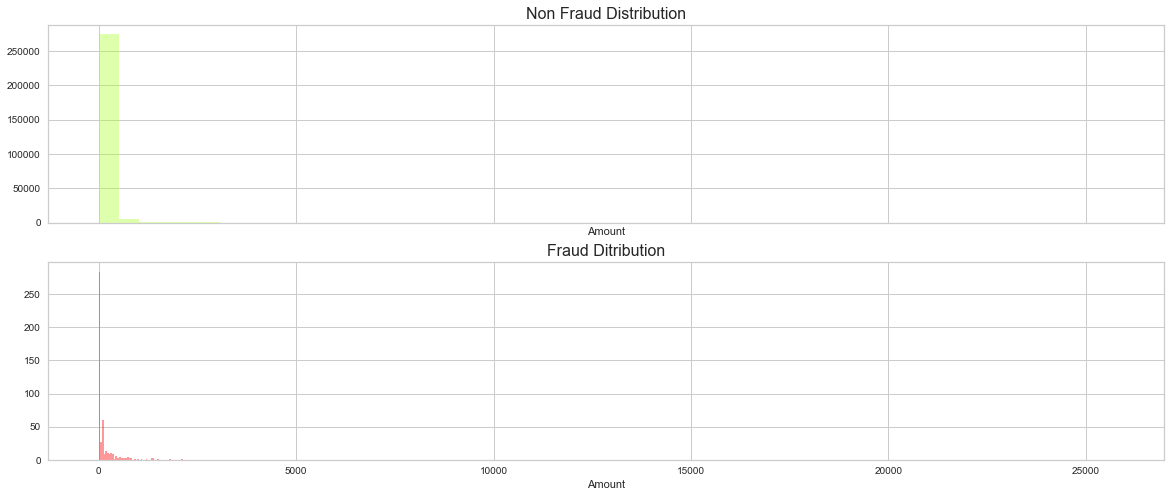

In [30]:
nonfraud_amount = data['Amount'][data['Class'] == "'0'"]
fraud_amount = data['Amount'][data['Class'] == "'1'"]
fig ,(ax1,ax2)=plt.subplots(nrows=2,ncols=1,sharex=True,figsize=[20,8])
sns.distplot(a=nonfraud_amount,bins=50,color='greenyellow',ax=ax1,kde=False)
ax1.set_title('Non Fraud Distribution',size=16)
sns.distplot(a=fraud_amount,bins=50,color='red',ax=ax2,kde=False)
ax2.set_title('Fraud Ditribution',size=16)
plt.show()

In [31]:
col_list = data.columns.to_list()
col_list.remove("Class")
print(col_list)

scaler = StandardScaler()

for i in col_list:
  data[i]=scaler.fit_transform(data[[i]])
  

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Time(in_hours)']


In [32]:
X = data.drop(labels = "Class",axis=1)
y = data['Class'].copy()

In [33]:
selector = SelectFromModel(estimator=RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)).fit(X, y)
selected_feat = X.columns[selector.get_support()].to_list()
print(f"Total features selected ::: {len(selected_feat)}")
print(f"threshold set by the model ::: {selector.threshold_}")
print(f"selected features are ::: {selected_feat}")

Total features selected ::: 7
threshold set by the model ::: 0.03225806451612903
selected features are ::: ['V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17']


C:\Users\admin\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


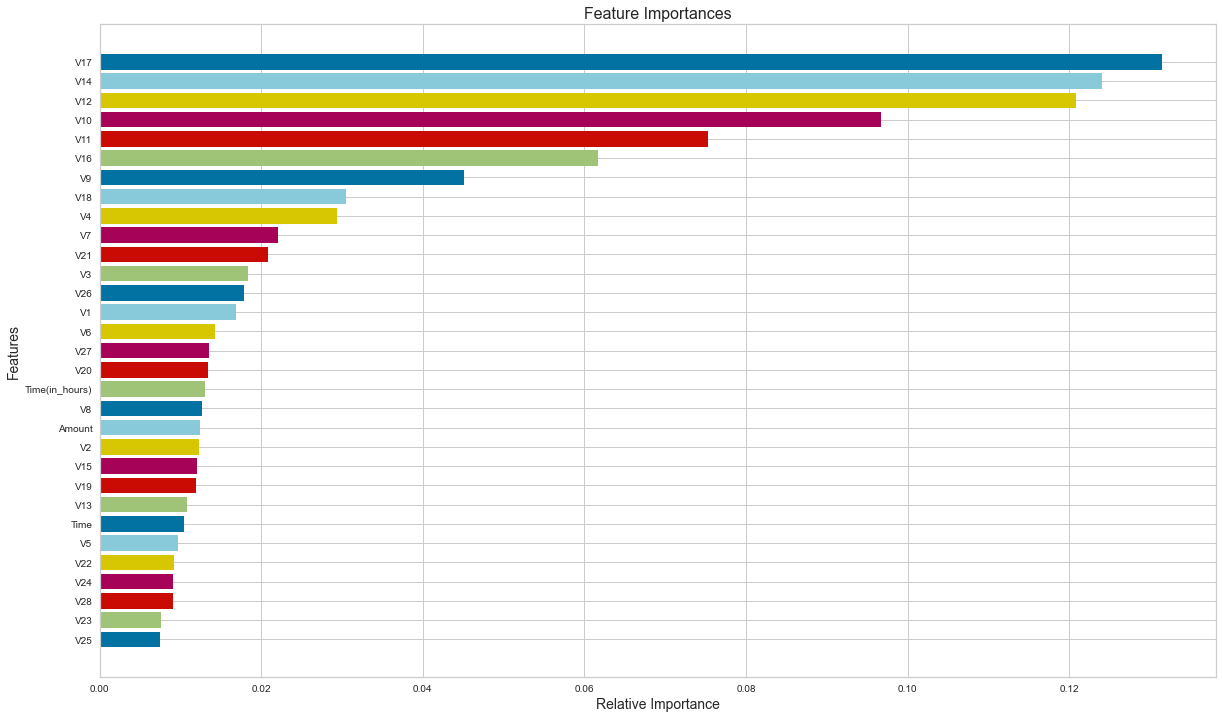

In [34]:
figure = plt.figure(figsize = [20, 12])
viz = FeatureImportances(selector.estimator_,relative=False)
viz.fit(X,y)
plt.xlabel('Relative Importance', size = 14)
plt.ylabel('Features', size = 14)
plt.title(label = 'Feature Importances', size = 16)
plt.show()

## Data Preparation

In [35]:
X = data[selected_feat].copy()
y = data['Class'].copy()

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42,stratify=y)
print(f"Training data shape :::: {X_train.shape} , {y_train.shape}")
print(f"Test data shape :::: {X_test.shape} , {y_test.shape}")

Training data shape :::: (255353, 7) , (255353,)
Test data shape :::: (28373, 7) , (28373,)


## Model Development and Evaluation

In [38]:
clf = GaussianNB()
clf.fit(X_train,y_train)
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

y_train_pred_proba = clf.predict_proba(X_train)
y_test_pred_proba = clf.predict_proba(X_test)


In [39]:
print("*****Classification report of train data  *****")
print(classification_report(y_train, y_train_pred)) 
print("*****Classification report of test data  *****")
print(classification_report(y_test, y_test_pred))

*****Classification report of train data  *****
              precision    recall  f1-score   support

         '0'       1.00      0.99      1.00    254927
         '1'       0.16      0.84      0.27       426

    accuracy                           0.99    255353
   macro avg       0.58      0.92      0.63    255353
weighted avg       1.00      0.99      0.99    255353

*****Classification report of test data  *****
              precision    recall  f1-score   support

         '0'       1.00      0.99      1.00     28326
         '1'       0.16      0.87      0.27        47

    accuracy                           0.99     28373
   macro avg       0.58      0.93      0.63     28373
weighted avg       1.00      0.99      0.99     28373



## SMOTE Technique and its Implementation

In [40]:
help(SMOTE)

Help on class SMOTE in module imblearn.over_sampling._smote.base:

class SMOTE(BaseSMOTE)
 |  SMOTE(*, sampling_strategy='auto', random_state=None, k_neighbors=5, n_jobs=None)
 |  
 |  Class to perform over-sampling using SMOTE.
 |  
 |  This object is an implementation of SMOTE - Synthetic Minority
 |  Over-sampling Technique as presented in [1]_.
 |  
 |  Read more in the :ref:`User Guide <smote_adasyn>`.
 |  
 |  Parameters
 |  ----------
 |  sampling_strategy : float, str, dict or callable, default='auto'
 |      Sampling information to resample the data set.
 |  
 |      - When ``float``, it corresponds to the desired ratio of the number of
 |        samples in the minority class over the number of samples in the
 |        majority class after resampling. Therefore, the ratio is expressed as
 |        :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
 |        number of samples in the minority class after resampling and
 |        :math:`N_{M}` is the number of sampl

In [44]:
sm = SMOTE(random_state=42)
X1, y1 = sm.fit_resample(X,y)

X_new = pd.DataFrame(data=X1,columns=X.columns)

(X_train1, X_test1,y_train1, y_test1) = train_test_split(X_new, y1, test_size = 0.2, random_state = 42, stratify = y1)

In [45]:
print(f"Training data shape :::: {X_train.shape} , {y_train.shape}")
print(f"Test data shape :::: {X_test.shape} , {y_test.shape}")

Training data shape :::: (453204, 7) , (453204,)
Test data shape :::: (113302, 7) , (113302,)


In [46]:
clf1 = GaussianNB()
clf1.fit(X_train1,y_train1)

y_train_pred1 = clf1.predict(X_train1)
y_test_pred1 = clf1.predict(X_test1)

y_train_pred1_proba = clf1.predict_proba(X_train1)
y_test_pred1_proba = clf1.predict_proba(X_test1)

In [47]:
print("*****Classification report of train data on oversampled data *****")
print(classification_report(y_train1, y_train_pred1)) 
print("*****Classification report of test data on oversampled data *****")
print(classification_report(y_test1, y_test_pred1))

*****Classification report of train data on oversampled data *****
              precision    recall  f1-score   support

         '0'       0.86      0.99      0.92    226602
         '1'       0.98      0.84      0.91    226602

    accuracy                           0.91    453204
   macro avg       0.92      0.91      0.91    453204
weighted avg       0.92      0.91      0.91    453204

*****Classification report of test data  *****
              precision    recall  f1-score   support

         '0'       0.86      0.98      0.92     56651
         '1'       0.98      0.84      0.91     56651

    accuracy                           0.91    113302
   macro avg       0.92      0.91      0.91    113302
weighted avg       0.92      0.91      0.91    113302

